In [7]:
import pandas as pd

In [8]:
files = [
    "hdbscan_line_mcs20_evaluation.csv",
    "hdbscan_node2vec_mcs50_evaluation.csv",
    "kmeans_line_k10_evaluation.csv",
    "kmeans_node2vec_k10_evaluation.csv",
    "louvain_evaluation_res0.5.csv",
    "lpa_evaluation.csv",
    "sslpa_cv_summary.csv",
]

In [9]:
for f in files:
    df = pd.read_csv(f)
    print(f"\n{f}")
    print(df.columns.tolist())


hdbscan_line_mcs20_evaluation.csv
['method', 'n_clusters', 'n_noise', 'noise_ratio', 'mean_size', 'max_size', 'min_size', 'median_size', 'std_size', 'modularity', 'coverage', 'conductance', 'nmi', 'ari', 'purity', 'labeled_coverage']

hdbscan_node2vec_mcs50_evaluation.csv
['method', 'n_clusters', 'n_noise', 'noise_ratio', 'mean_size', 'max_size', 'min_size', 'median_size', 'std_size', 'modularity', 'coverage', 'conductance', 'nmi', 'ari', 'purity', 'labeled_coverage']

kmeans_line_k10_evaluation.csv
['method', 'n_clusters', 'mean_size', 'max_size', 'min_size', 'median_size', 'std_size', 'modularity', 'coverage', 'conductance', 'nmi', 'ari', 'purity', 'labeled_coverage']

kmeans_node2vec_k10_evaluation.csv
['method', 'n_clusters', 'mean_size', 'max_size', 'min_size', 'median_size', 'std_size', 'modularity', 'coverage', 'conductance', 'nmi', 'ari', 'purity', 'labeled_coverage']

louvain_evaluation_res0.5.csv
['method', 'n_clusters', 'mean_size', 'max_size', 'min_size', 'median_size', 's

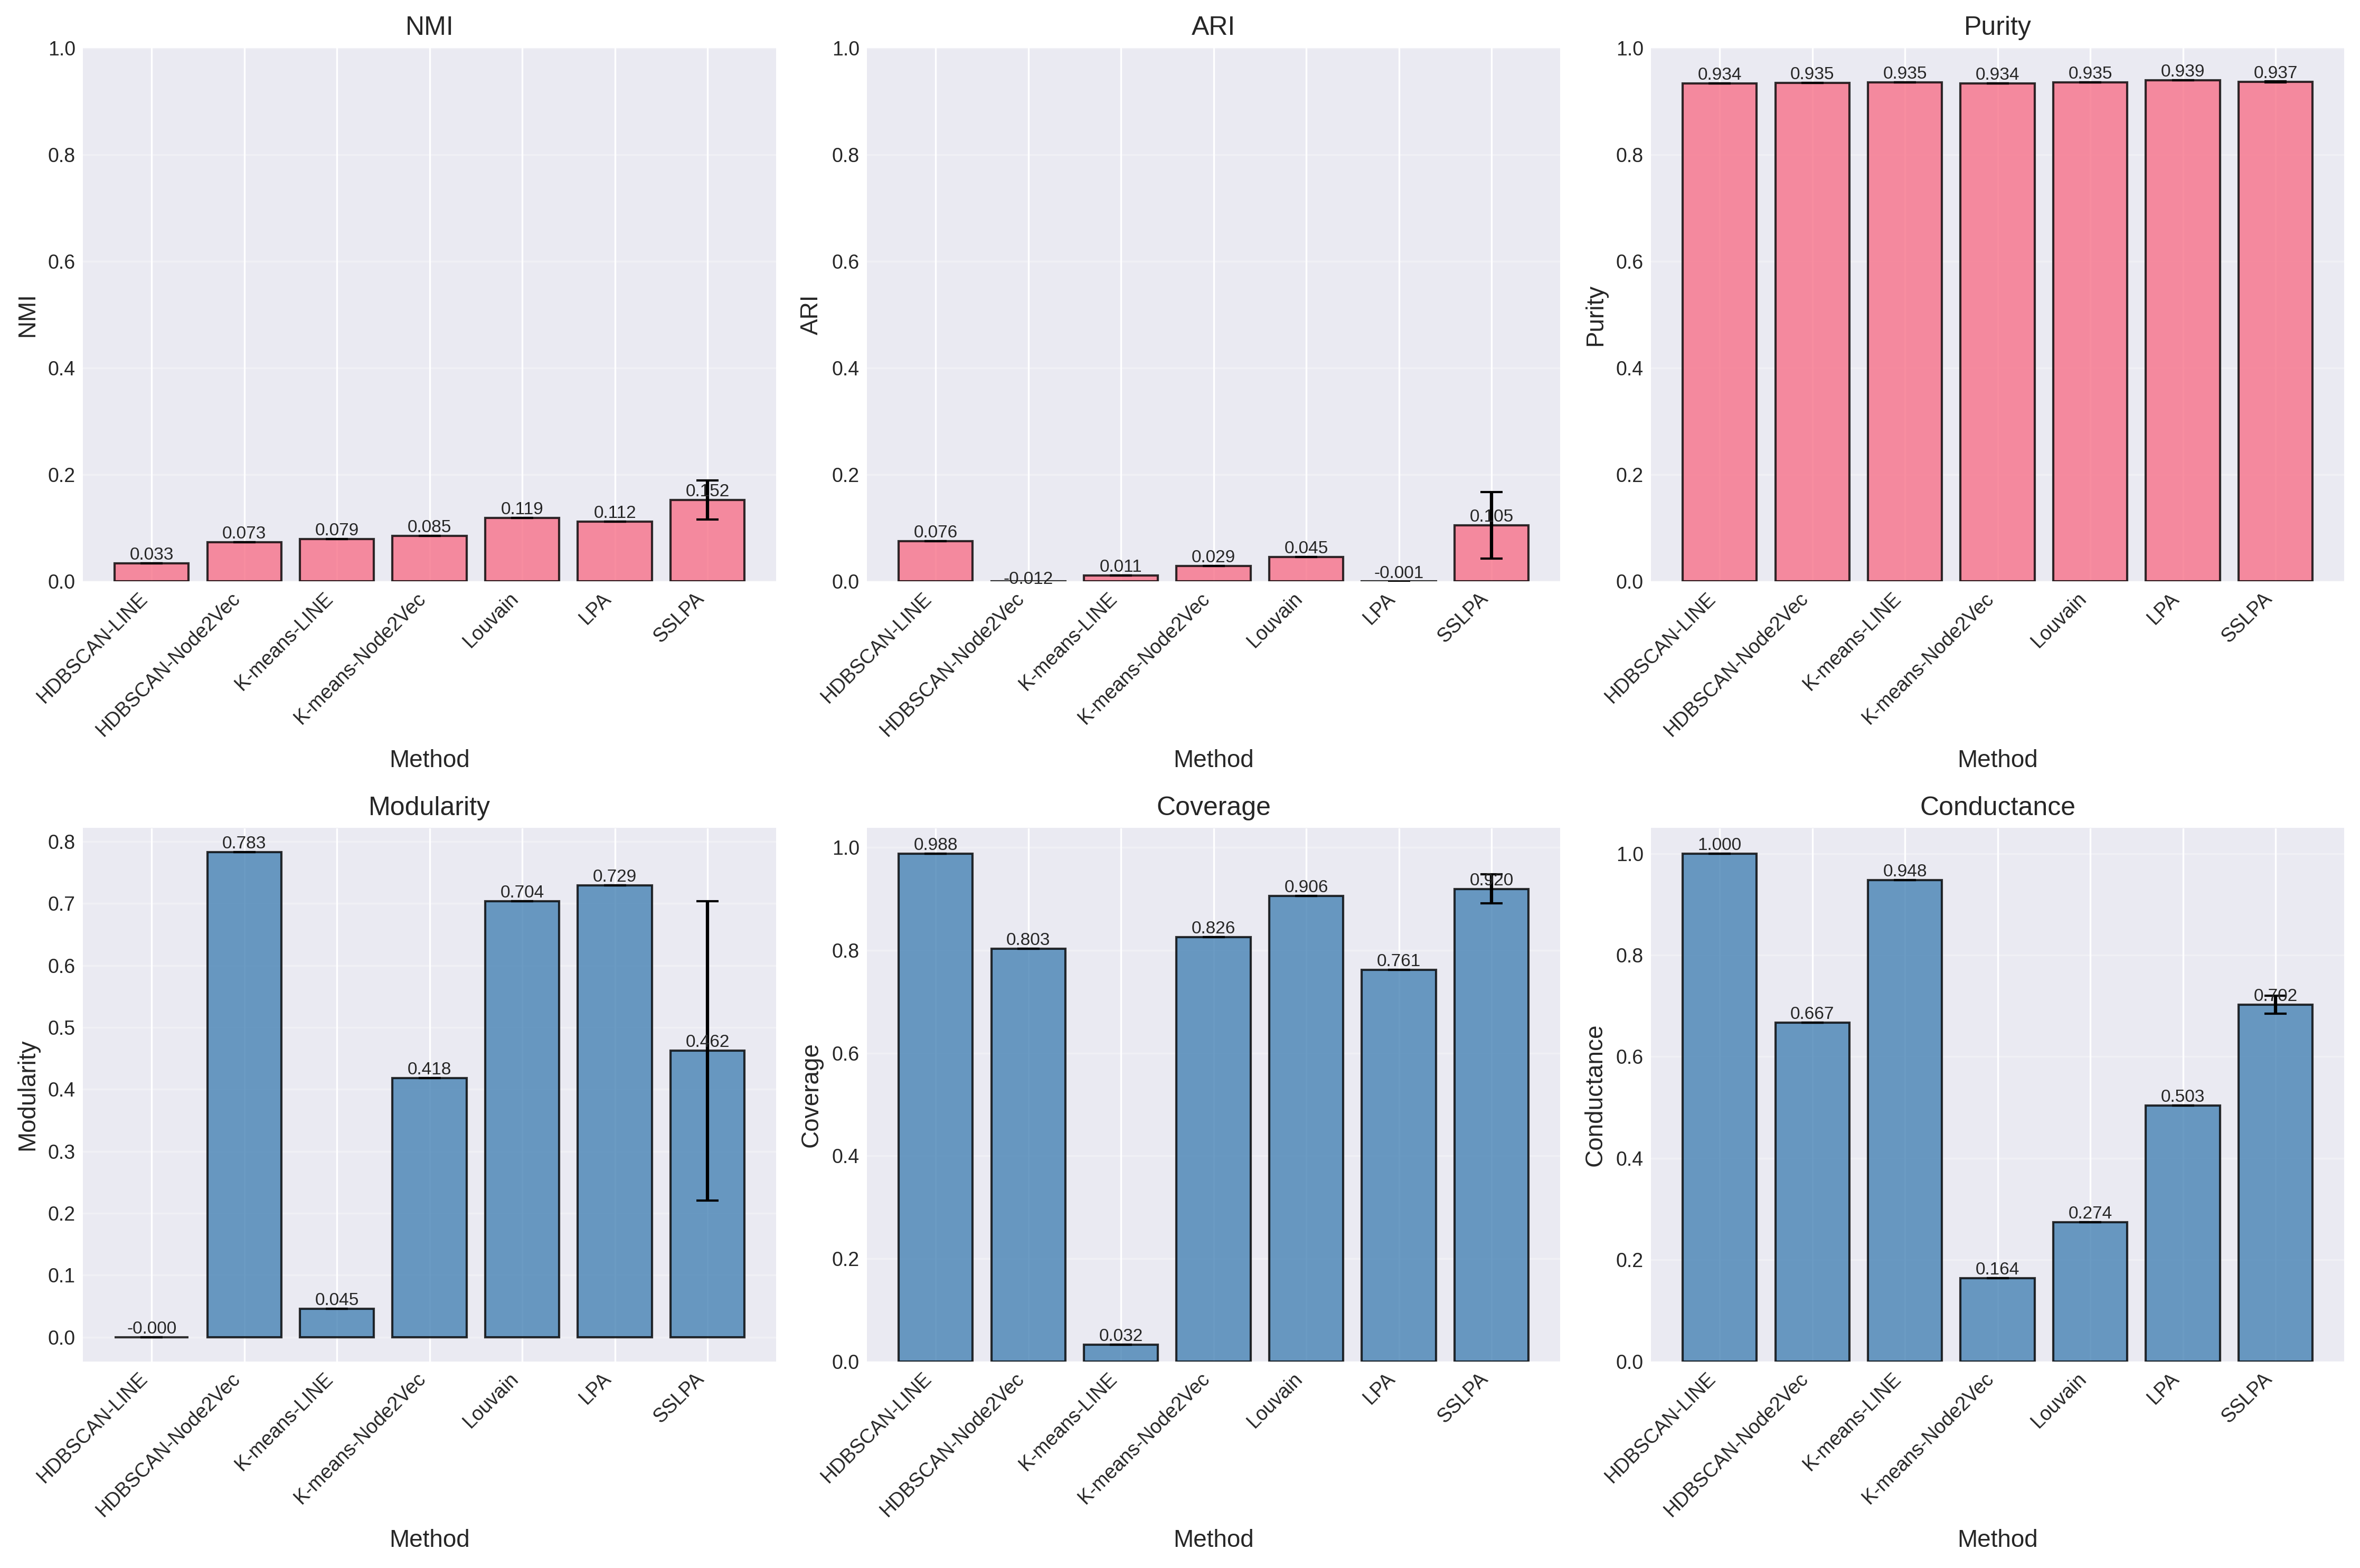

Saved: clustering_comparison.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data_files = {
    'HDBSCAN-LINE': 'hdbscan_line_mcs20_evaluation.csv',
    'HDBSCAN-Node2Vec': 'hdbscan_node2vec_mcs50_evaluation.csv',
    'K-means-LINE': 'kmeans_line_k10_evaluation.csv',
    'K-means-Node2Vec': 'kmeans_node2vec_k10_evaluation.csv',
    'Louvain': 'louvain_evaluation_res0.5.csv',
    'LPA': 'lpa_evaluation.csv',
    'SSLPA': 'sslpa_cv_summary.csv'
}

results = {}
for name, file in data_files.items():
    results[name] = pd.read_csv(file)

metrics_data = []
for method_name, df in results.items():
    if method_name == 'SSLPA':
        metrics_data.append({
            'Method': method_name,
            'NMI': df['nmi_mean'].iloc[0],
            'NMI_std': df['nmi_std'].iloc[0],
            'ARI': df['ari_mean'].iloc[0],
            'ARI_std': df['ari_std'].iloc[0],
            'Purity': df['purity_mean'].iloc[0],
            'Purity_std': df['purity_std'].iloc[0],
            'Modularity': df['modularity_mean'].iloc[0],
            'Modularity_std': df['modularity_std'].iloc[0],
            'Coverage': df['coverage_mean'].iloc[0],
            'Coverage_std': df['coverage_std'].iloc[0],
            'Conductance': df['conductance_mean'].iloc[0],
            'Conductance_std': df['conductance_std'].iloc[0],
        })
    else:
        row = df.iloc[0]
        metrics_data.append({
            'Method': method_name,
            'NMI': row['nmi'],
            'NMI_std': 0,
            'ARI': row['ari'],
            'ARI_std': 0,
            'Purity': row['purity'],
            'Purity_std': 0,
            'Modularity': row['modularity'],
            'Modularity_std': 0,
            'Coverage': row['coverage'],
            'Coverage_std': 0,
            'Conductance': row['conductance'],
            'Conductance_std': 0,
        })

comparison_df = pd.DataFrame(metrics_data)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

external_metrics = ['NMI', 'ARI', 'Purity']
for idx, metric in enumerate(external_metrics):
    ax = axes[0, idx]
    x_pos = np.arange(len(comparison_df))
    
    bars = ax.bar(x_pos, comparison_df[metric], 
                   yerr=comparison_df[f'{metric}_std'],
                   capsize=5, alpha=0.8, edgecolor='black')
    
    ax.set_xlabel('Method')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric}')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(comparison_df['Method'], rotation=45, ha='right')
    ax.set_ylim([0, 1.0])
    ax.grid(axis='y', alpha=0.3)
    
    for bar, val in zip(bars, comparison_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

internal_metrics = ['Modularity', 'Coverage', 'Conductance']
for idx, metric in enumerate(internal_metrics):
    ax = axes[1, idx]
    x_pos = np.arange(len(comparison_df))
    
    bars = ax.bar(x_pos, comparison_df[metric],
                   yerr=comparison_df[f'{metric}_std'],
                   capsize=5, alpha=0.8, edgecolor='black', color='steelblue')
    
    ax.set_xlabel('Method')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric}')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(comparison_df['Method'], rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)
    
    for bar, val in zip(bars, comparison_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('clustering_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: clustering_comparison.png")